In [12]:
import cupy as cp
print("CuPy version:", cp.__version__)
print("CUDA available:", cp.cuda.is_available())
if cp.cuda.is_available():
    print("Driver version:", cp.cuda.runtime.driverGetVersion())
    print("Runtime version:", cp.cuda.runtime.runtimeGetVersion())

CuPy version: 14.0.1
CUDA available: False


In [4]:
import os
import numpy as np
from fipy import *
from tqdm import tqdm  
import scipy.ndimage as ndi
DTYPE = np.float64

# ---------- CPU kernel ----------
def _kernels(dx, dy, dtype=DTYPE):
    kx  = np.asarray([[0,0,0],[-1,0,1],[0,0,0]], dtype=dtype) / (2*dx)
    ky  = np.asarray([[0,-1,0],[0,0,0],[0,1,0]], dtype=dtype) / (2*dy)
    kxx = np.asarray([[0,0,0],[1,-2,1],[0,0,0]], dtype=dtype) / (dx*dx)
    kyy = np.asarray([[0,1,0],[0,-2,0],[0,1,0]], dtype=dtype) / (dy*dy)
    return kx, ky, (kxx + kyy)

# ---------- CPU time stepping (explicit Euler, Neumann 0) ----------
def solve_diffusion(u0_np, nu, dt, steps, dx, dy):
    kx, ky, klap = _kernels(dx, dy)
    u = np.asarray(u0_np, dtype=DTYPE)
    lap = np.empty_like(u)
    for _ in range(steps):
        ndi.correlate(u, klap, mode='nearest', output=lap)
        u = u + dt * (nu * lap)
    return u

def solve_advection(u0_np, vel, dt, steps, dx, dy):
    kx, ky, _ = _kernels(dx, dy)
    u = np.asarray(u0_np, dtype=DTYPE)
    dudx = np.empty_like(u); dudy = np.empty_like(u)
    for _ in range(steps):
        ndi.correlate(u, kx, mode='nearest', output=dudx)
        ndi.correlate(u, ky, mode='nearest', output=dudy)
        u = u - dt * vel * (dudx + dudy)
    return u

def solve_advdiff(u0_np, vel, nu, dt, steps, dx, dy):
    kx, ky, klap = _kernels(dx, dy)
    u = np.asarray(u0_np, dtype=DTYPE)
    dudx = np.empty_like(u); dudy = np.empty_like(u); lap = np.empty_like(u)
    for _ in range(steps):
        ndi.correlate(u, kx,   mode='nearest', output=dudx)
        ndi.correlate(u, ky,   mode='nearest', output=dudy)
        ndi.correlate(u, klap, mode='nearest', output=lap)
        u = u - dt * vel * (dudx + dudy) + dt * (nu * lap)
    return u

# Directories
train_folder = "train_data64_500"
test_folder = "test_data64_cal"
calibration_folder = "calibration_data64"


os.makedirs(train_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True)
os.makedirs(calibration_folder, exist_ok=True)
# Set up the 2D domain and mesh
nx = 64
ny = 64
Lx = 1
Ly = 1
dx = Lx / nx
dy = Ly / ny
mesh = Grid2D(dx=dx, dy=dy, nx=nx, ny=ny)
x, y = mesh.cellCenters[0], mesh.cellCenters[1]

# Simulation time parameters optimized by Bongseok
timeStep = 0.0001
steps = 500

# Number of datasets to generate
num_datasets = 2000

# Loop with tqdm progress bar
for i in tqdm(range(num_datasets), desc="Generating datasets"):
    # Fixed coefficients ##################################################
    diffusivity = 0.25
    velocity_x = 4
    velocity_y = 2
    vel = numerix.sqrt(velocity_x**2 + velocity_y**2)

    # ----------- Advection-Diffusion Simulation ----------------##
    center_x = np.random.uniform(0.2 * Lx, 0.8 * Lx)
    center_y = np.random.uniform(0.2 * Ly, 0.8 * Ly)
    initial_width = np.random.uniform(0.02, 0.08)
    x, y = mesh.cellCenters
    init_val_adv_diff = np.exp(-(((x - center_x)**2 + (y - center_y)**2) / initial_width))
    taper = numerix.sin(numerix.pi*x) * numerix.sin(numerix.pi*y)
    init_val_adv_diff = init_val_adv_diff * taper

    # CPU calculation
    U_adv_diff = solve_advdiff(init_val_adv_diff.reshape(nx, ny),
                               float(vel), float(diffusivity), float(timeStep), steps, float(dx), float(dy))
    phi_adv_diff = CellVariable(name="phi_adv_diff", mesh=mesh, value=U_adv_diff.ravel())
    

    # ----------- Diffusion Only Simulation ----------------##
    center_x = np.random.uniform(0.2 * Lx, 0.8 * Lx)
    center_y = np.random.uniform(0.2 * Ly, 0.8 * Ly)
    initial_width = np.random.uniform(0.02, 0.08)
    x, y = mesh.cellCenters
    init_val_diff = np.exp(-(((x - center_x)**2 + (y - center_y)**2) / initial_width))
    taper = numerix.sin(numerix.pi*x) * numerix.sin(numerix.pi*y)
    init_val_diff = init_val_diff * taper
    # CPU calculation
    U_diff = solve_diffusion(init_val_diff.reshape(nx, ny),
                                 float(diffusivity), float(timeStep), steps, float(dx), float(dy))
    phi_diff = CellVariable(name="phi_diff", mesh=mesh, value=U_diff.ravel())

    # ----------- Advection Only Simulation ----------------##
    center_x = np.random.uniform(0.2 * Lx, 0.8 * Lx)
    center_y = np.random.uniform(0.2 * Ly, 0.8 * Ly)
    initial_width = np.random.uniform(0.02, 0.08)
    x, y = mesh.cellCenters
    init_val_adve = np.exp(-(((x - center_x)**2 + (y - center_y)**2) / initial_width))
    taper = numerix.sin(numerix.pi*x) * numerix.sin(numerix.pi*y)
    init_val_adve = init_val_adve * taper

    # CPU calculation
    U_adve = solve_advection(init_val_adve.reshape(nx, ny),
                                 float(vel), float(timeStep), steps, float(dx), float(dy))
    phi_adv = CellVariable(name="phi_adv", mesh=mesh, value=U_adve.ravel())

    # ----------- save ----------------##
    # if i < int(0.9 * num_datasets):
    #     save_folder = train_folder
    # else:
    # save_folder = test_folder
    save_folder = train_folder
    # save_folder = calibration_folder

    filename_diff = os.path.join(save_folder, f"dataset_2d_{i:05d}_diff.npz")
    filename_adve = os.path.join(save_folder, f"dataset_2d_{i:05d}_adve.npz")
    filename_adve_diff = os.path.join(save_folder, f"dataset_2d_{i:05d}_adve_diff.npz")

    size = 64*64
    # save diff dataset
    pattern = np.array([1, 0, 0]).reshape(-1, 1)
    one_hot = np.zeros((size, 1))
    one_hot[:len(one_hot) // 3 * 3] = np.tile(pattern, (size // 3, 1))
    np.savez(filename_diff,
             last_value=phi_diff.value,        
             init_value=init_val_diff,
             label=0,
             one_hot=one_hot,
             diffusivity=diffusivity,
             velocity_x=velocity_x,
             velocity_y=velocity_y)

    # save adve dataset
    pattern = np.array([0, 1, 0]).reshape(-1, 1)
    one_hot = np.zeros((size, 1))
    one_hot[:len(one_hot) // 3 * 3] = np.tile(pattern, (size // 3, 1))
    # np.savez(filename_adve,
    #          last_value=phi_adv.value,           
    #          init_value=init_val_adve,
    #          label=1,
    #          one_hot=one_hot,
    #          diffusivity=diffusivity,
    #          velocity_x=velocity_x,
    #          velocity_y=velocity_y)

    # save adve_diff dataset
    pattern = np.array([0, 0, 1]).reshape(-1, 1)
    one_hot = np.zeros((size, 1))
    one_hot[:len(one_hot) // 3 * 3] = np.tile(pattern, (size // 3, 1))
    # np.savez(filename_adve_diff,
    #          last_value=phi_adv_diff.value,      
    #          init_value=init_val_adv_diff,
    #          label=2,
    #          one_hot=one_hot,
    #          diffusivity=diffusivity,
    #          velocity_x=velocity_x,
    #          velocity_y=velocity_y)

    # print(one_hot.shape)
    del phi_adv_diff, phi_diff, phi_adv
    del init_val_adv_diff, init_val_diff, init_val_adve
    del filename_diff, filename_adve, filename_adve_diff
    del save_folder
    del i
    del x, y

Generating datasets: 100%|██████████| 2000/2000 [02:42<00:00, 12.30it/s]


In [5]:
import matplotlib.pyplot as plt

# ----- config -----
nx, ny = 64, 64
folder = "test_data64_cal"   # 혹은 "test_data4"
k = 0             

f_diff   = os.path.join(folder, f"dataset_2d_{k:05d}_diff.npz")
f_adve   = os.path.join(folder, f"dataset_2d_{k:05d}_adve.npz")
f_advdiff= os.path.join(folder, f"dataset_2d_{k:05d}_adve_diff.npz")

D  = np.load(f_diff)
A  = np.load(f_adve)
AD = np.load(f_advdiff)

u0 = D["init_value"].reshape(nx, ny)     # IC of diff
u_diff = D["last_value"].reshape(nx, ny)
u_adve = A["last_value"].reshape(nx, ny)
u_advd = AD["last_value"].reshape(nx, ny)

# vmin = min(u0.min(), u_diff.min(), u_adve.min(), u_advd.min())
# vmax = max(u0.max(), u_diff.max(), u_adve.max(), u_advd.max())

# ----- plot -----
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

im0 = axes[0].imshow(u0, origin="lower", cmap="viridis")
axes[0].set_title("Initial Condition")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(u_diff, origin="lower", cmap="viridis")
axes[1].set_title("Diffusion")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(u_adve, origin="lower", cmap="viridis")
axes[2].set_title("Advection")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(u_advd, origin="lower", cmap="viridis")
axes[3].set_title("Advection–Diffusion")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'test_data64_cal/dataset_2d_00000_diff.npz'

In [6]:
def generate_random_mask(shape, coverage=0.25, seed=None):
    """Create a random binary mask with a given coverage fraction.

    Args:
        shape: tuple of ints, the mask shape.
        coverage: float between 0 and 1, fraction of pixels to mask.
        seed: optional int for reproducible masks.

    Returns:
        np.ndarray of shape `shape` with 1.0 for visible pixels and 0.0 for masked pixels.
    """
    if seed is not None:
        np.random.seed(seed)
    total = np.prod(shape)
    num_masked = int(total * coverage)
    mask = np.ones(total, dtype=np.float32)
    if num_masked > 0:
        indices = np.random.choice(total, size=num_masked, replace=False)
        mask[indices] = 0.0
    return mask.reshape(shape)

coverage = 0.75  # fraction of pixels to mask; modify this value as needed
mask = generate_random_mask(u0.shape, coverage=coverage, seed=42)
print("mask shape:", mask.shape)
print("requested coverage:", coverage)
print("actual masked fraction:", np.mean(mask == 0.0))

u0_masked = u0 * mask
u_diff_masked = u_diff * mask
u_adve_masked = u_adve * mask
u_advd_masked = u_advd * mask

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
images = [u0, u0_masked, u_diff, u_diff_masked, u_adve, u_adve_masked, u_advd, u_advd_masked]
titles = [
    "Initial Condition", "Initial Condition (masked)",
    "Diffusion", "Diffusion (masked)",
    "Advection", "Advection (masked)",
    "Advection–Diffusion", "Advection–Diffusion (masked)"
]
for ax, img, title in zip(axes.flat, images, titles):
    im = ax.imshow(img, origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


NameError: name 'u0' is not defined

In [14]:
# Make 2-channel data for diffusion, advection, and advection-diffusion simulations

import os
import numpy as np
from fipy import *
from tqdm import tqdm  
import scipy.ndimage as ndi
DTYPE = np.float64

# ---------- CPU kernel ----------
def _kernels(dx, dy, dtype=DTYPE):
    kx  = np.asarray([[0,0,0],[-1,0,1],[0,0,0]], dtype=dtype) / (2*dx)
    ky  = np.asarray([[0,-1,0],[0,0,0],[0,1,0]], dtype=dtype) / (2*dy)
    kxx = np.asarray([[0,0,0],[1,-2,1],[0,0,0]], dtype=dtype) / (dx*dx)
    kyy = np.asarray([[0,1,0],[0,-2,0],[0,1,0]], dtype=dtype) / (dy*dy)
    return kx, ky, (kxx + kyy)

# ---------- CPU time stepping (explicit Euler, Neumann 0) ----------
def solve_diffusion(u0_np, nu, dt, steps, dx, dy):
    kx, ky, klap = _kernels(dx, dy)
    u = np.asarray(u0_np, dtype=DTYPE)
    lap = np.empty_like(u)
    for _ in range(steps):
        ndi.correlate(u, klap, mode='nearest', output=lap)
        u = u + dt * (nu * lap)
    return u

def solve_advection(u0_np, vel, dt, steps, dx, dy):
    kx, ky, _ = _kernels(dx, dy)
    u = np.asarray(u0_np, dtype=DTYPE)
    dudx = np.empty_like(u); dudy = np.empty_like(u)
    for _ in range(steps):
        ndi.correlate(u, kx, mode='nearest', output=dudx)
        ndi.correlate(u, ky, mode='nearest', output=dudy)
        u = u - dt * vel * (dudx + dudy)
    return u

def solve_advdiff(u0_np, vel, nu, dt, steps, dx, dy):
    kx, ky, klap = _kernels(dx, dy)
    u = np.asarray(u0_np, dtype=DTYPE)
    dudx = np.empty_like(u); dudy = np.empty_like(u); lap = np.empty_like(u)
    for _ in range(steps):
        ndi.correlate(u, kx,   mode='nearest', output=dudx)
        ndi.correlate(u, ky,   mode='nearest', output=dudy)
        ndi.correlate(u, klap, mode='nearest', output=lap)
        u = u - dt * vel * (dudx + dudy) + dt * (nu * lap)
    return u

# Create output directories for organized 2-channel data
output_base = "test_data"
folders_2ch = {
    'diff': os.path.join(output_base, 'Diffusion'),
    'adve': os.path.join(output_base, 'Advection'),
    'adve_diff': os.path.join(output_base, 'Advection-Diffusion'),
}

for folder in folders_2ch.values():
    os.makedirs(folder, exist_ok=True)

print(f"Creating 2-channel data in:")
for pde_type, path in folders_2ch.items():
    print(f"  {pde_type}: {path}/")
print()

# Set up the 2D domain and mesh
nx = 64
ny = 64
Lx = 1
Ly = 1
dx = Lx / nx
dy = Ly / ny
mesh = Grid2D(dx=dx, dy=dy, nx=nx, ny=ny)
x, y = mesh.cellCenters[0], mesh.cellCenters[1]

# Simulation time parameters
timeStep = 0.0001
steps = 500

# Number of datasets to generate
num_datasets = 100  # Adjust as needed

# Loop with tqdm progress bar
for i in tqdm(range(num_datasets), desc="Generating 2-channel datasets"):
    # Fixed coefficients
    diffusivity = 0.25
    velocity_x = 4
    velocity_y = 2
    vel = numerix.sqrt(velocity_x**2 + velocity_y**2)

    # # ----------- Advection-Diffusion Simulation ----------------
    # center_x = np.random.uniform(0.2 * Lx, 0.8 * Lx)
    # center_y = np.random.uniform(0.2 * Ly, 0.8 * Ly)
    # initial_width = np.random.uniform(0.02, 0.08)
    # x_mesh, y_mesh = mesh.cellCenters
    # init_val_adv_diff = np.exp(-(((x_mesh - center_x)**2 + (y_mesh - center_y)**2) / initial_width))
    # taper = numerix.sin(numerix.pi*x_mesh) * numerix.sin(numerix.pi*y_mesh)
    # init_val_adv_diff = init_val_adv_diff * taper

    # U_adv_diff = solve_advdiff(init_val_adv_diff.reshape(nx, ny),
    #                            float(vel), float(diffusivity), float(timeStep), steps, float(dx), float(dy))
    
    # Create 2-channel data: [init, final]
    # two_ch_adv_diff = np.stack([init_val_adv_diff, U_adv_diff.ravel()], axis=0)
    
    # ----------- Diffusion Only Simulation ----------------
    center_x = np.random.uniform(0.2 * Lx, 0.8 * Lx)
    center_y = np.random.uniform(0.2 * Ly, 0.8 * Ly)
    initial_width = np.random.uniform(0.02, 0.08)
    x_mesh, y_mesh = mesh.cellCenters
    init_val_diff = np.exp(-(((x_mesh - center_x)**2 + (y_mesh - center_y)**2) / initial_width))
    taper = numerix.sin(numerix.pi*x_mesh) * numerix.sin(numerix.pi*y_mesh)
    init_val_diff = init_val_diff * taper

    U_diff = solve_diffusion(init_val_diff.reshape(nx, ny),
                             float(diffusivity), float(timeStep), steps, float(dx), float(dy))
    
    # Create 2-channel data: [init, final]
    two_ch_diff = np.stack([init_val_diff, U_diff.ravel()], axis=0)

    # ----------- Advection Only Simulation ----------------
    # center_x = np.random.uniform(0.2 * Lx, 0.8 * Lx)
    # center_y = np.random.uniform(0.2 * Ly, 0.8 * Ly)
    # initial_width = np.random.uniform(0.02, 0.08)
    # x_mesh, y_mesh = mesh.cellCenters
    # init_val_adve = np.exp(-(((x_mesh - center_x)**2 + (y_mesh - center_y)**2) / initial_width))
    # taper = numerix.sin(numerix.pi*x_mesh) * numerix.sin(numerix.pi*y_mesh)
    # init_val_adve = init_val_adve * taper

    # U_adve = solve_advection(init_val_adve.reshape(nx, ny),
    #                          float(vel), float(timeStep), steps, float(dx), float(dy))
    
    # # Create 2-channel data: [init, final]
    # two_ch_adve = np.stack([init_val_adve, U_adve.ravel()], axis=0)

    # ----------- Save 2-channel data ----------------
    # Save Diffusion
    filename_diff = os.path.join(folders_2ch['diff'], f"dataset_2d_{i:05d}.npz")
    np.savez(filename_diff,
             data=two_ch_diff,
             init_value=init_val_diff,
             final_value=U_diff.ravel(),
             label=0,
             diffusivity=diffusivity,
             velocity_x=velocity_x,
             velocity_y=velocity_y)

    # # Save Advection
    # filename_adve = os.path.join(folders_2ch['adve'], f"dataset_2d_{i:05d}.npz")
    # np.savez(filename_adve,
    #          data=two_ch_adve,
    #          init_value=init_val_adve,
    #          final_value=U_adve.ravel(),
    #          label=1,
    #          diffusivity=diffusivity,
    #          velocity_x=velocity_x,
    #          velocity_y=velocity_y)

    # # Save Advection-Diffusion
    # filename_adve_diff = os.path.join(folders_2ch['adve_diff'], f"dataset_2d_{i:05d}.npz")
    # np.savez(filename_adve_diff,
    #          data=two_ch_adv_diff,
    #          init_value=init_val_adv_diff,
    #          final_value=U_adv_diff.ravel(),
    #          label=2,
    #          diffusivity=diffusivity,
    #          velocity_x=velocity_x,
    #          velocity_y=velocity_y)

    # Cleanup
    del U_diff, # U_adv_diff, U_adve
    del init_val_diff, # init_val_adv_diff, init_val_adve
    del two_ch_diff, # two_ch_adve, two_ch_adv_diff

print("\n✓ Complete! Generated 2-channel data:")
print(f"  Diffusion: {folders_2ch['diff']}/")
print(f"  Advection: {folders_2ch['adve']}/")
print(f"  Advection-Diffusion: {folders_2ch['adve_diff']}/")

Creating 2-channel data in:
  diff: test_data/Diffusion/
  adve: test_data/Advection/
  adve_diff: test_data/Advection-Diffusion/



Generating 2-channel datasets: 100%|██████████| 100/100 [00:01<00:00, 56.62it/s]


✓ Complete! Generated 2-channel data:
  Diffusion: test_data/Diffusion/
  Advection: test_data/Advection/
  Advection-Diffusion: test_data/Advection-Diffusion/



Diffusion:
  File: dataset_2d_00000.npz
  Channel 0 (initial): min=0.0000, max=0.7094
  Channel 1 (final): min=0.0000, max=0.2584

Advection:
  File: dataset_2d_00000.npz
  Channel 0 (initial): min=0.0000, max=0.9498
  Channel 1 (final): min=-0.0011, max=0.9554

Advection-Diffusion:
  File: dataset_2d_00000.npz
  Channel 0 (initial): min=0.0000, max=0.6716
  Channel 1 (final): min=0.0000, max=0.2512


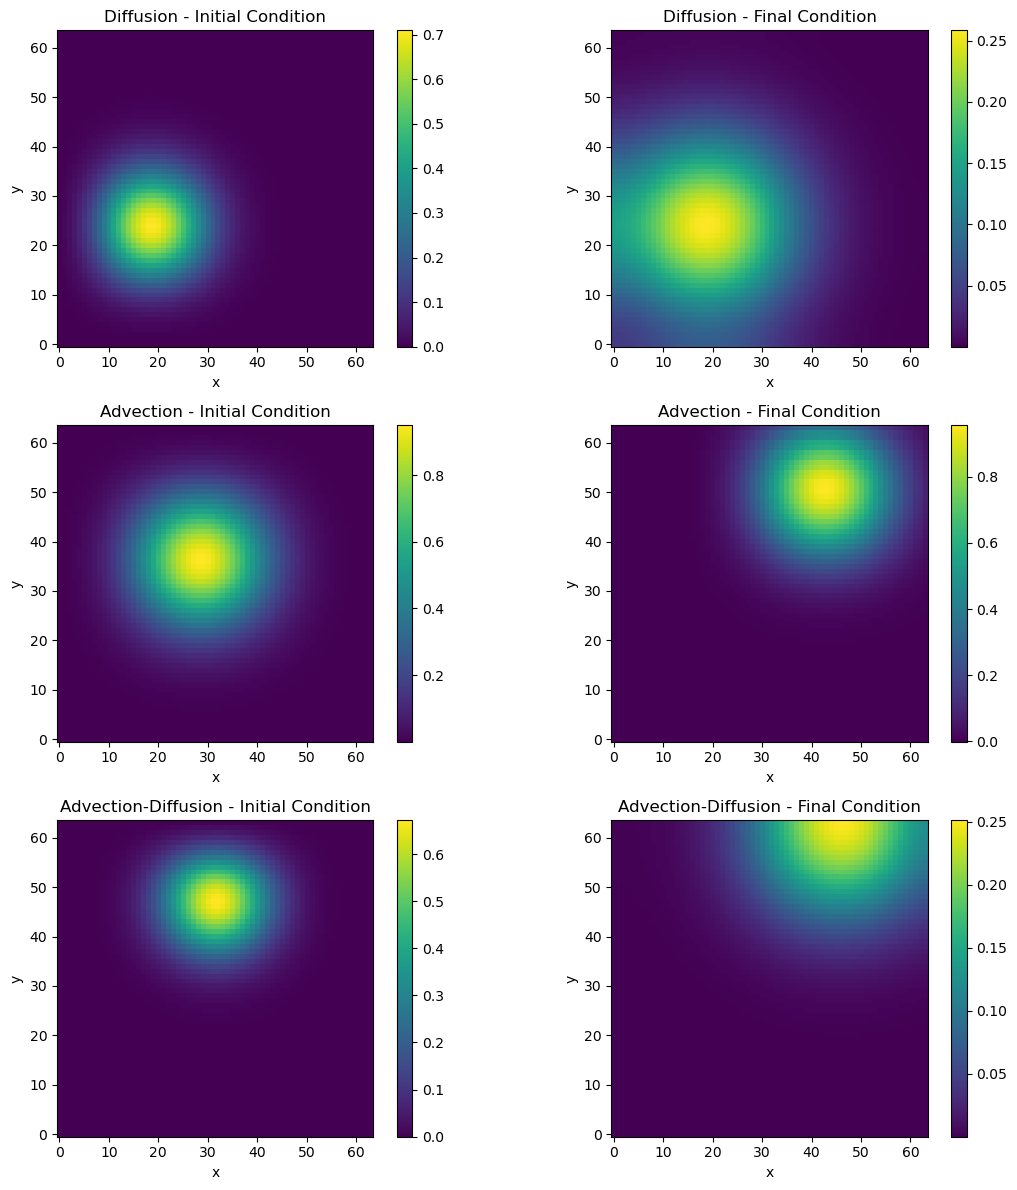

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Load and visualize example from each PDE type
output_base = "train_data"
pde_types = ['Diffusion', 'Advection', 'Advection-Diffusion']

fig, axes = plt.subplots(len(pde_types), 2, figsize=(12, 4*len(pde_types)))

for row, pde_type in enumerate(pde_types):
    folder_path = os.path.join(output_base, pde_type)
    
    # Find first available file
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npz')])
    if not files:
        print(f"No files found in {folder_path}")
        continue
    
    # Load first file
    data_file = os.path.join(folder_path, files[0])
    data = np.load(data_file)
    
    # Extract 2-channel data and reshape to (64, 64)
    two_channel = data['data']  # Shape: (2, 4096)
    init_channel = two_channel[0].reshape(64, 64)
    final_channel = two_channel[1].reshape(64, 64)
    
    # Plot initial condition
    im0 = axes[row, 0].imshow(init_channel, origin='lower', cmap='viridis')
    axes[row, 0].set_title(f'{pde_type} - Initial Condition')
    axes[row, 0].set_xlabel('x')
    axes[row, 0].set_ylabel('y')
    fig.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)
    
    # Plot final condition
    im1 = axes[row, 1].imshow(final_channel, origin='lower', cmap='viridis')
    axes[row, 1].set_title(f'{pde_type} - Final Condition')
    axes[row, 1].set_xlabel('x')
    axes[row, 1].set_ylabel('y')
    fig.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)
    
    print(f"\n{pde_type}:")
    print(f"  File: {files[0]}")
    print(f"  Channel 0 (initial): min={init_channel.min():.4f}, max={init_channel.max():.4f}")
    print(f"  Channel 1 (final): min={final_channel.min():.4f}, max={final_channel.max():.4f}")
    
    data.close()

plt.tight_layout()
plt.show()